# RecSys Learning

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
listings = pd.read_csv("listings_df.csv")
presents = pd.read_csv("presents_df.csv")
transactions = pd.read_csv("transactions_df.csv")
listing_views = pd.read_csv("listings_view_df.csv")
users = pd.read_csv("users_df.csv")

In [3]:
listings.head()

,listing_id,present_id,seller_id,status_id,price,blockchain_tx_hash,created_at,updated_at
0,1,17,1,2,2.00,44076831bdfb9c10eea4609ac5d5efc0f7c8d8c32d2115...,2026-04-24 10:04:33.860784,2026-04-24 16:18:44.994410
1,2,22,16,1,10.00,NaN,2026-04-24 17:27:27.979196,2026-04-29 17:47:16.651635
2,3,28,17,2,1502.00,15e795d6ae3a855f9f7cc68d10abcff318e52244a016bb...,2026-04-24 18:00:12.182984,2026-04-27 06:27:20.077044
3,4,29,17,2,0.01,6131fa4789dbb73b4e9e405e303b61d380f0d99caa1725...,2026-04-24 18:01:52.627305,2026-04-27 06:29:50.453839
4,5,31,18,1,1000.00,NaN,2026-04-24 18:12:51.718141,2026-05-06 17:10:24.875302


In [4]:
presents.head()

,present_id,collection_id,model_id,background_id,symbol_id,present_num,image_url,generated_at,is_burned,description,is_visible,original_sender_id
0,2,1,29.0,17.0,481.0,1,generated_e59baadbf09b4917bd650259802ba622.png,2026-04-27 05:51:06.286198,0,NaN,1,2
1,3,5,323.0,32.0,394.0,1,generated_4185562bc2cb4ce29d9799af7785c79b.png,2026-04-24 09:59:46.440513,0,ура 2025,1,1
2,4,58,3904.0,43.0,45.0,1,generated_a7ed190fec4e4cb590a257329302fba6.png,2026-04-24 09:59:49.045898,0,хехе хитрый тыква,1,1
3,5,30,1958.0,67.0,670.0,1,generated_767b7f36261545118c696d87bdf72a9f.png,2026-04-24 18:22:35.635907,0,держи какаху #1,0,1
4,6,4,255.0,23.0,285.0,1,generated_96b6ed21e12f4bf5a1e888b0ba13a515.png,2026-04-27 05:51:09.289261,0,клубничка для сладенькой,1,1


In [5]:
transactions.head()

,transaction_id,buyer_id,seller_id,present_id,type_id,status_id,transaction_price,platform_fee,seller_received,blockchain_tx_hash,block_number,transaction_date,created_at
0,1,2,2,2,1,2,20.0,0.0,20.0,f83613549b38a4699edbd1ead9680a37a066d944b0e9cd...,8,2026-04-03 21:38:07.357852,2026-04-03 21:38:07.364932
1,2,1,1,3,1,2,1.0,0.0,1.0,8300bab21d92d3d8a598615586ada9abdd919538890a33...,6,2026-04-04 10:57:54.798153,2026-04-04 10:57:54.805484
2,3,1,1,4,1,2,1.0,0.0,1.0,2ce64b4f27a8a9a07fabee225e54be9c1e4a4798cd69c3...,7,2026-04-04 11:00:52.351498,2026-04-04 11:00:52.354701
3,4,5,1,5,1,2,1.0,0.0,1.0,5d53ff2f2189fc3b9f526f587a70797c07273578834eab...,8,2026-04-04 11:01:37.143155,2026-04-04 11:01:37.151241
4,5,2,1,6,1,2,1.0,0.0,1.0,577bf3fe57fdb00e5ac583e0878a1366fa5118d4cebab8...,9,2026-04-04 11:02:11.764946,2026-04-04 11:02:11.767329


In [6]:
listing_views.head()

,user_id,listing_id
0,3,2
1,13,5
2,13,7
3,23,7
4,1,13


In [7]:
users.head()

,user_id,role_id,user_tg_id,user_vk_id,tg_username,vk_username,tg_visibility,vk_visibility,username,profile_pic_url,wallet_address,wallet_private_key_encrypted,wallet_encryption_version,wallet_created_at,is_active,created_at,about_me
0,1,3,868752299,191144284.0,jdm_enjoyerr,vk_user_191144284,0,0,JDM_enjoyer1007,5a84dca61df34d13870831be1c884ac4.jpg,0xa5066c77aEDb0036C260f93f3a6290f7e519CE63,gAAAAABpxrQG6vG_Te4C00u25765vi7vj0OG6bVVSZAQ78...,1,2026-03-27 16:44:54.146793,1,2026-03-24 20:47:51.235998,VIP User
1,2,3,8052361559,NaN,cursed_supp,NaN,0,1,lyublyu_blondinok,419c6a879f0f434583783dc3f1dff70e.jpg,0xa0ef4982b0Fc6230c14F54becAffC4bD14F20E77,gAAAAABpxrQoxKdK9c1ikrEm-0EDB3SraLHdCiivRMwQK4...,1,2026-03-27 16:45:28.807612,1,2026-03-24 21:27:46.623502,ЛЮБЛЮ БЛОНДИНОКЛЮБЛЮ БЛОНДИНОКЛЮБЛЮ БЛОНДИНОКЛ...
2,3,2,8754635637,NaN,erik_tryhard_developer,NaN,0,1,zxcursed228,0526b317116c406f9a8a0d93189a4bcd.jpg,0x9ce92B819bA0273377621C3Df51F1EaA47f4C316,gAAAAABpxrQ7z7zbTKyyXXStKT-U2LaM8xNApXV5kPzQZd...,1,2026-03-27 16:45:47.782466,1,2026-03-24 21:28:11.783528,?From Ufa
3,4,1,1867061412,NaN,Alfamod_ik,NaN,1,1,Alfamod_ik,8a61e5a4a5d847ebaa7a8eb92549aede.jpg,0xcB3eBD5136691A03F7A2E3C72e43a4aD45aA107b,gAAAAABpxrRQEXFBCeFZzWWmf8_RIyt1iRuTTvTehbKrpx...,1,2026-03-27 16:46:08.749556,1,2026-03-26 13:55:27.763797,NaN
4,5,2,1451355915,NaN,d3v4stated,NaN,0,1,I_love_kami,d4f74708043347389feff1f1eac6dae7.jpg,0x2FE542861d326d449e9b16204Ad18b00C05e5834,gAAAAABpxrcSmjx0feUmjJjzsK8VD8Lj8Fl2zWF5n2F9bb...,1,2026-03-27 16:57:54.787858,1,2026-03-26 14:35:15.270269,ЛЮБЛЮ КАМИЛЛУ


In [8]:
print(listings.shape)
print(presents.shape)
print(transactions.shape)
print(listing_views.shape)
print(users.shape)

(438, 8)
(239, 12)
(572, 13)
(236, 2)
(21, 17)


In [9]:
user_listing_views = (
    listing_views
    .groupby(["user_id", "listing_id"])
    .size()
    .reset_index(name="views_count")
)

data = listings.merge(user_listing_views, on="listing_id", how="left")
data["views_count"] = data["views_count"].fillna(0).astype(int)

In [10]:
data.head()

,listing_id,present_id,seller_id,status_id,price,blockchain_tx_hash,created_at,updated_at,user_id,views_count
0,1,17,1,2,2.00,44076831bdfb9c10eea4609ac5d5efc0f7c8d8c32d2115...,2026-04-24 10:04:33.860784,2026-04-24 16:18:44.994410,NaN,0
1,2,22,16,1,10.00,NaN,2026-04-24 17:27:27.979196,2026-04-29 17:47:16.651635,3.0,1
2,3,28,17,2,1502.00,15e795d6ae3a855f9f7cc68d10abcff318e52244a016bb...,2026-04-24 18:00:12.182984,2026-04-27 06:27:20.077044,NaN,0
3,4,29,17,2,0.01,6131fa4789dbb73b4e9e405e303b61d380f0d99caa1725...,2026-04-24 18:01:52.627305,2026-04-27 06:29:50.453839,NaN,0
4,5,31,18,1,1000.00,NaN,2026-04-24 18:12:51.718141,2026-05-06 17:10:24.875302,13.0,1


In [11]:
data.shape

(541, 10)

In [12]:
data = data.merge(users, on="user_id", how="left")

In [13]:
data.head()

,listing_id,present_id,seller_id,status_id,price,blockchain_tx_hash,created_at_x,updated_at,user_id,views_count,...,vk_visibility,username,profile_pic_url,wallet_address,wallet_private_key_encrypted,wallet_encryption_version,wallet_created_at,is_active,created_at_y,about_me
0,1,17,1,2,2.00,44076831bdfb9c10eea4609ac5d5efc0f7c8d8c32d2115...,2026-04-24 10:04:33.860784,2026-04-24 16:18:44.994410,NaN,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,22,16,1,10.00,NaN,2026-04-24 17:27:27.979196,2026-04-29 17:47:16.651635,3.0,1,...,1.0,zxcursed228,0526b317116c406f9a8a0d93189a4bcd.jpg,0x9ce92B819bA0273377621C3Df51F1EaA47f4C316,gAAAAABpxrQ7z7zbTKyyXXStKT-U2LaM8xNApXV5kPzQZd...,1.0,2026-03-27 16:45:47.782466,1.0,2026-03-24 21:28:11.783528,?From Ufa
2,3,28,17,2,1502.00,15e795d6ae3a855f9f7cc68d10abcff318e52244a016bb...,2026-04-24 18:00:12.182984,2026-04-27 06:27:20.077044,NaN,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,29,17,2,0.01,6131fa4789dbb73b4e9e405e303b61d380f0d99caa1725...,2026-04-24 18:01:52.627305,2026-04-27 06:29:50.453839,NaN,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5,31,18,1,1000.00,NaN,2026-04-24 18:12:51.718141,2026-05-06 17:10:24.875302,13.0,1,...,1.0,ЗОЛОТОЙМАГНАТ,6349a6a90fee4b079115eade903aabaa.jpg,0xCce871D778b00E014cC13B1094837a5149aC74d9,gAAAAABpyqdUYyzzoRGJFn-Gj8DTcVmmy5tdvEijG5w-oS...,1.0,2026-03-30 16:39:48.865225,1.0,2026-03-30 16:39:48.830278,ЗОЛОТО ЗОЛОТО ЗОЛОТО ЗОЛОТО ЗОЛОТО ЗОЛОТО ЗОЛОТО


In [14]:
data.shape

(541, 26)

In [15]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 541 entries, 0 to 540
Data columns (total 26 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   listing_id                    541 non-null    int64  
 1   present_id                    541 non-null    int64  
 2   seller_id                     541 non-null    int64  
 3   status_id                     541 non-null    int64  
 4   price                         541 non-null    float64
 5   blockchain_tx_hash            115 non-null    str    
 6   created_at_x                  541 non-null    str    
 7   updated_at                    541 non-null    str    
 8   user_id                       236 non-null    float64
 9   views_count                   541 non-null    int64  
 10  role_id                       236 non-null    float64
 11  user_tg_id                    236 non-null    float64
 12  user_vk_id                    45 non-null     float64
 13  tg_username     

In [16]:
data = data.drop(columns=["blockchain_tx_hash", 'created_at_y', 'updated_at', 'created_at_x', 'role_id', 'user_tg_id', 'user_vk_id', 'username', 'profile_pic_url', 'wallet_address', 'wallet_private_key_encrypted', 'wallet_encryption_version', 'wallet_created_at', 'is_active', 'about_me', 'tg_username', 'vk_username', 'tg_visibility', 'vk_visibility'])

In [17]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 541 entries, 0 to 540
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   listing_id   541 non-null    int64  
 1   present_id   541 non-null    int64  
 2   seller_id    541 non-null    int64  
 3   status_id    541 non-null    int64  
 4   price        541 non-null    float64
 5   user_id      236 non-null    float64
 6   views_count  541 non-null    int64  
dtypes: float64(2), int64(5)
memory usage: 29.7 KB


In [18]:
data = data.merge(presents, on="present_id", how="left")

In [19]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 541 entries, 0 to 540
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   listing_id          541 non-null    int64  
 1   present_id          541 non-null    int64  
 2   seller_id           541 non-null    int64  
 3   status_id           541 non-null    int64  
 4   price               541 non-null    float64
 5   user_id             236 non-null    float64
 6   views_count         541 non-null    int64  
 7   collection_id       541 non-null    int64  
 8   model_id            541 non-null    float64
 9   background_id       541 non-null    float64
 10  symbol_id           541 non-null    float64
 11  present_num         541 non-null    int64  
 12  image_url           541 non-null    str    
 13  generated_at        541 non-null    str    
 14  is_burned           541 non-null    int64  
 15  description         161 non-null    str    
 16  is_visible         

In [20]:
data = data.drop(columns=['image_url', 'generated_at', 'is_burned', 'description', 'is_visible', 'original_sender_id'])

In [21]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 541 entries, 0 to 540
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   listing_id     541 non-null    int64  
 1   present_id     541 non-null    int64  
 2   seller_id      541 non-null    int64  
 3   status_id      541 non-null    int64  
 4   price          541 non-null    float64
 5   user_id        236 non-null    float64
 6   views_count    541 non-null    int64  
 7   collection_id  541 non-null    int64  
 8   model_id       541 non-null    float64
 9   background_id  541 non-null    float64
 10  symbol_id      541 non-null    float64
 11  present_num    541 non-null    int64  
dtypes: float64(5), int64(7)
memory usage: 50.8 KB


In [22]:
data = data[data['status_id'] == 1]
data = data.drop(columns=['status_id'])

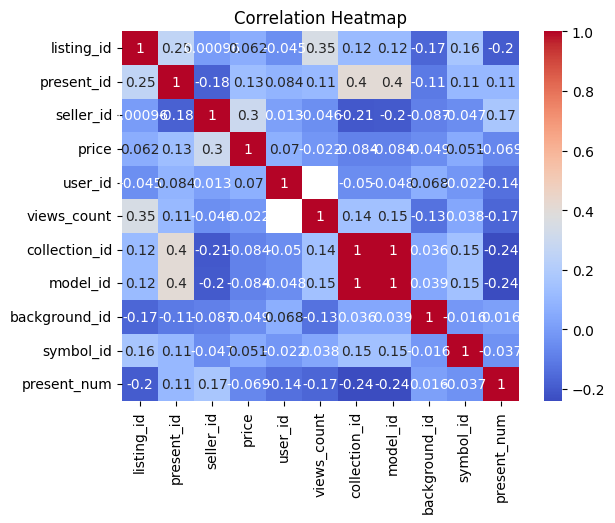

<Figure size 1800x1400 with 0 Axes>

In [23]:
sns.heatmap(data.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.figure(figsize=(18, 14))
plt.show()

In [24]:
users_pivot = data.pivot_table(index='user_id', columns='listing_id', values='views_count', fill_value=0)
users_pivot.head()

listing_id,2,5,7,13,130,131,132,133,139,143,...,424,426,427,428,429,431,432,433,437,438
user_id,,,,,,,,,,,,,,,,,,,,,
1.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,...,0.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,1.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0
3.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,...,0.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0
4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [25]:
def samelots(lot):
    users_vote_lot = users_pivot[lot]
    similar_lots = users_pivot.corrwith(users_vote_lot)
    similar_lots = pd.DataFrame(similar_lots, columns=['correlation'])
    print(similar_lots)
    df = similar_lots.sort_values(by='correlation', ascending=False).head(10)
    print(df)
    df_sort = df[df['correlation'] > 0.6]
    return df_sort[1:]

In [26]:
samelots(433)

            correlation
listing_id             
2              0.408248
5             -0.272166
7             -0.408248
13             0.102062
130            0.408248
...                 ...
431            0.408248
432            0.000000
433            1.000000
437           -0.089087
438            0.102062

[127 rows x 1 columns]
            correlation
listing_id             
433            1.000000
213            0.801784
429            0.666667
133            0.612372
131            0.612372
2              0.408248
195            0.408248
199            0.408248
211            0.408248
311            0.408248


,correlation
listing_id,
213,0.801784
429,0.666667
133,0.612372
131,0.612372


## From similar lots to For You recommendations

The idea is to turn implicit feedback into a user-item matrix, calculate item-item similarity, then score active lots from the listings a user already viewed or bought.

In [27]:
active_listing_meta = (
    data[[
        "listing_id",
        "present_id",
        "price",
        "collection_id",
        "model_id",
        "background_id",
        "symbol_id",
        "present_num",
    ]]
    .drop_duplicates("listing_id")
    .reset_index(drop=True)
)

view_interactions = listing_views.assign(weight=1.0)

purchase_interactions = (
    transactions.merge(listings[["listing_id", "present_id"]], on="present_id", how="inner")
    .rename(columns={"buyer_id": "user_id"})
    [["user_id", "listing_id"]]
    .assign(weight=3.0)
)

interactions = pd.concat(
    [view_interactions[["user_id", "listing_id", "weight"]], purchase_interactions],
    ignore_index=True,
)
interactions = interactions.dropna(subset=["user_id", "listing_id"])
interactions[["user_id", "listing_id"]] = interactions[["user_id", "listing_id"]].astype(int)
interactions = interactions.groupby(["user_id", "listing_id"], as_index=False)["weight"].sum()

interactions.head()

,user_id,listing_id,weight
0,1,1,9.0
1,1,3,6.0
2,1,4,6.0
3,1,6,6.0
4,1,8,6.0


In [28]:
def build_item_similarity(interactions_df):
    user_item_matrix = interactions_df.pivot_table(
        index="user_id",
        columns="listing_id",
        values="weight",
        aggfunc="sum",
        fill_value=0,
    )
    similarity = user_item_matrix.corr(min_periods=1).fillna(0)
    similarity = similarity.mask(np.eye(similarity.shape[0], dtype=bool), 0)
    return user_item_matrix, similarity


user_item, item_similarity = build_item_similarity(interactions)
item_similarity.head()

listing_id,1,2,3,4,5,6,7,8,9,10,...,429,430,431,432,433,434,435,436,437,438
listing_id,,,,,,,,,,,,,,,,,,,,,
1,0.000000,-0.131501,0.687730,0.835101,-0.131501,0.780235,-0.150287,0.835101,0.780235,0.949133,...,0.294742,0.936282,0.116563,0.552793,0.077358,-0.049124,-0.049124,-0.049124,0.147371,0.018786
2,-0.131501,0.000000,-0.144699,-0.144699,-0.096838,-0.114914,-0.110672,-0.144699,-0.114914,-0.107530,...,-0.118860,-0.114914,-0.145398,-0.196467,-0.123700,-0.144699,-0.144699,-0.144699,-0.144699,-0.110672
3,0.687730,-0.144699,0.000000,0.797297,-0.144699,0.686837,-0.165371,0.594595,0.686837,0.743128,...,-0.081081,0.686837,-0.119101,0.164399,-0.093635,-0.216216,-0.216216,-0.216216,0.324324,-0.010336
4,0.835101,-0.144699,0.797297,0.000000,-0.144699,0.686837,-0.165371,0.797297,0.686837,0.893762,...,-0.081081,0.901473,-0.119101,0.349348,0.097891,-0.013514,-0.013514,-0.013514,-0.081081,-0.010336
5,-0.131501,-0.096838,-0.144699,-0.144699,0.000000,-0.114914,0.986166,0.320406,-0.114914,-0.107530,...,-0.118860,-0.114914,-0.145398,-0.196467,-0.148114,-0.144699,-0.144699,-0.144699,-0.144699,-0.110672


In [29]:
def popularity_fallback(interactions_df, candidate_meta, top_k=10, exclude_ids=None):
    exclude_ids = set(exclude_ids or [])
    candidate_ids = set(candidate_meta["listing_id"]) - exclude_ids

    scores = (
        interactions_df[interactions_df["listing_id"].isin(candidate_ids)]
        .groupby("listing_id")["weight"]
        .sum()
        .sort_values(ascending=False)
        .head(top_k)
        .rename("score")
        .reset_index()
    )

    if scores.empty:
        scores = candidate_meta[["listing_id"]].head(top_k).assign(score=0.0)

    return scores.merge(candidate_meta, on="listing_id", how="left")


def recommend_for_user(
    user_id,
    user_item_matrix,
    similarity,
    interactions_df,
    candidate_meta,
    top_k=10,
):
    if user_id not in user_item_matrix.index:
        return popularity_fallback(interactions_df, candidate_meta, top_k=top_k)

    user_vector = user_item_matrix.loc[user_id]
    seen = user_vector[user_vector > 0]
    seen_ids = set(seen.index)

    candidate_ids = pd.Index(candidate_meta["listing_id"]).intersection(similarity.index)
    source_ids = seen.index.intersection(similarity.columns)

    if source_ids.empty or candidate_ids.empty:
        return popularity_fallback(interactions_df, candidate_meta, top_k=top_k, exclude_ids=seen_ids)

    scores = similarity.loc[candidate_ids, source_ids].dot(seen.loc[source_ids])
    scores = scores.drop(index=seen_ids, errors="ignore")
    scores = scores.sort_values(ascending=False).head(top_k)

    if scores.empty:
        return popularity_fallback(interactions_df, candidate_meta, top_k=top_k, exclude_ids=seen_ids)

    return scores.rename("score").reset_index().merge(candidate_meta, on="listing_id", how="left")

In [30]:
example_user_id = int(user_item.index[0])
recommend_for_user(
    example_user_id,
    user_item,
    item_similarity,
    interactions,
    active_listing_meta,
    top_k=10,
)

,listing_id,score,present_id,price,collection_id,model_id,background_id,symbol_id,present_num
0,138,284.380956,125,20.0,49,3265.0,79.0,309.0,1
1,176,284.380956,180,4.0,30,1988.0,24.0,76.0,4
2,142,284.380956,129,3.0,49,3280.0,60.0,50.0,5
3,144,284.380956,135,5.0,33,2130.0,59.0,293.0,5
4,154,284.380956,145,4.0,8,448.0,11.0,436.0,3
5,151,284.380956,139,10.0,2,67.0,75.0,240.0,5
6,148,284.380956,142,3.0,2,77.0,55.0,525.0,7
7,147,284.380956,134,3.0,33,2140.0,61.0,586.0,4
8,146,284.380956,136,2.0,33,2116.0,79.0,75.0,6
9,152,284.380956,137,4.0,2,78.0,7.0,93.0,3


In [31]:
def leave_one_out_split(interactions_df, candidate_ids, random_state=42):
    candidate_ids = set(candidate_ids)
    eligible = interactions_df[interactions_df["listing_id"].isin(candidate_ids)].copy()
    user_counts = eligible.groupby("user_id")["listing_id"].transform("count")
    eligible = eligible[user_counts >= 2]

    if eligible.empty:
        return interactions_df.copy(), eligible[["user_id", "listing_id"]]

    test = eligible.groupby("user_id", group_keys=False).sample(n=1, random_state=random_state)
    train = interactions_df.merge(
        test[["user_id", "listing_id"]],
        on=["user_id", "listing_id"],
        how="left",
        indicator=True,
    )
    train = train[train["_merge"] == "left_only"].drop(columns="_merge")
    return train, test[["user_id", "listing_id"]]


def recall_at_k(interactions_df, candidate_meta, k=10):
    train, test = leave_one_out_split(interactions_df, candidate_meta["listing_id"])
    train_user_item, train_similarity = build_item_similarity(train)

    hits = 0
    evaluated_users = 0

    for row in test.itertuples(index=False):
        recs = recommend_for_user(
            row.user_id,
            train_user_item,
            train_similarity,
            train,
            candidate_meta,
            top_k=k,
        )
        recommended_ids = set(recs["listing_id"])
        hits += int(row.listing_id in recommended_ids)
        evaluated_users += 1

    return hits / evaluated_users if evaluated_users else 0


recall_at_k(interactions, active_listing_meta, k=10)

0.15384615384615385

## Save trained recommendation model

This cell saves the trained recommendation artifact. The application loads this file and uses ready ranked listing IDs instead of recalculating the training algorithm in backend.

In [32]:
from datetime import datetime, timezone
from pathlib import Path
import pickle

MODEL_TOP_K = 100
MODEL_PATH = Path("../backend/ml/recsys_model.pkl")
MODEL_PATH.parent.mkdir(parents=True, exist_ok=True)

popular_listing_ids = (
    popularity_fallback(
        interactions,
        active_listing_meta,
        top_k=MODEL_TOP_K,
    )["listing_id"]
    .astype(int)
    .tolist()
)

recommendations_by_user = {}

for user_id in user_item.index:
    user_id = int(user_id)
    user_recs = recommend_for_user(
        user_id,
        user_item,
        item_similarity,
        interactions,
        active_listing_meta,
        top_k=MODEL_TOP_K,
    )["listing_id"].astype(int).tolist()

    seen_listing_ids = set(user_item.loc[user_id][user_item.loc[user_id] > 0].index.astype(int))
    for listing_id in popular_listing_ids:
        if listing_id not in user_recs and listing_id not in seen_listing_ids:
            user_recs.append(listing_id)

    recommendations_by_user[user_id] = user_recs[:MODEL_TOP_K]

recsys_model = {
    "version": 1,
    "model_type": "item_item_collaborative_filtering_precomputed",
    "created_at": datetime.now(timezone.utc).isoformat(),
    "top_k": MODEL_TOP_K,
    "recommendations_by_user": recommendations_by_user,
    "popular_listing_ids": popular_listing_ids,
    "metadata": {
        "users_count": int(user_item.shape[0]),
        "items_count": int(user_item.shape[1]),
        "interactions_count": int(len(interactions)),
        "active_candidates_count": int(len(active_listing_meta)),
        "view_weight": 1.0,
        "purchase_weight": 3.0,
    },
}

with MODEL_PATH.open("wb") as file:
    pickle.dump(recsys_model, file)

MODEL_PATH, recsys_model["metadata"]

(WindowsPath('../backend/ml/recsys_model.pkl'),
 {'users_count': 15,
  'items_count': 438,
  'interactions_count': 947,
  'active_candidates_count': 180,
  'view_weight': 1.0,
  'purchase_weight': 3.0})